# Install MediaPipe

In [10]:
!pip install protobuf==4.25.3
!pip install mediapipe==0.10.14

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 6.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
proto-plus 1.28.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.3 which is incompatible.
google-cloud-bigquery-connection 1.22.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.3 which is incompatible.
google-cloud-translate 3.27.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.3 which is incompatible.
google-cloud-functions 1.24.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.3 which is incompatible.
google-api-core 2.30.3 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.3 which is incompatible.
grain 0.2.18 requires protobuf>=5.28.3, but you have protobuf 4.25.3 which is incompatible.
google-cloud-datastore 2.25.0 requires protobuf<8.0.0,>=4.25.8, but you have proto

  Using cached mediapipe-0.10.14-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.7 kB)
Using cached mediapipe-0.10.14-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (35.7 MB)


In [1]:
!pip install mediapipe==0.10.21

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 93.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.2/81.2 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 7.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninst

In [1]:
import mediapipe as mp

print("MediaPipe Version:", mp.__version__)
print("Has solutions:", hasattr(mp, "solutions"))

MediaPipe Version: 0.10.21
Has solutions: True


In [2]:
mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils

hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.5
)

print("MediaPipe loaded successfully!")

MediaPipe loaded successfully!


In [3]:
import sys
import mediapipe as mp

print("Python:", sys.version)
print("MediaPipe:", mp.__version__)
print("Has solutions:", hasattr(mp, "solutions"))

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
MediaPipe: 0.10.21
Has solutions: True


In [4]:
!pip install mediapipe opencv-python

INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 12.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.13.0.92
    Uninstalling opencv-python-4.13.0.92:
      Successfully uninstalled opencv-python-4.13.0.92
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires tensorflow>=2.2.0, which is not installed.


# Import Libraries

In [1]:
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
import os

# Initialize MediaPipe Hands

In [2]:
mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils

hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.5
)

# Download the dataset again

In [4]:
import kagglehub

path = kagglehub.dataset_download("shyambhu/hands-and-palm-images-dataset")

print(path)

Using Colab cache for faster access to the 'hands-and-palm-images-dataset' dataset.
/kaggle/input/hands-and-palm-images-dataset


In [5]:
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

In [6]:
csv_path = os.path.join(path, "HandInfo.csv")

df = pd.read_csv(csv_path)

print(df.head())

   id  age gender skinColor  accessories  nailPolish  aspectOfHand  \
0   0   27   male      fair            0           0  dorsal right   
1   0   27   male      fair            0           0  dorsal right   
2   0   27   male      fair            0           0  dorsal right   
3   0   27   male      fair            0           0  dorsal right   
4   0   27   male      fair            0           0  dorsal right   

          imageName  irregularities  
0  Hand_0000002.jpg               0  
1  Hand_0000003.jpg               0  
2  Hand_0000004.jpg               0  
3  Hand_0000005.jpg               0  
4  Hand_0000006.jpg               0  


In [7]:
image_folder = os.path.join(path, "Hands", "Hands")

print(image_folder)

/kaggle/input/hands-and-palm-images-dataset/Hands/Hands


In [8]:
image_name = df.loc[0, "imageName"]

image_path = os.path.join(image_folder, image_name)

print(image_path)

/kaggle/input/hands-and-palm-images-dataset/Hands/Hands/Hand_0000002.jpg


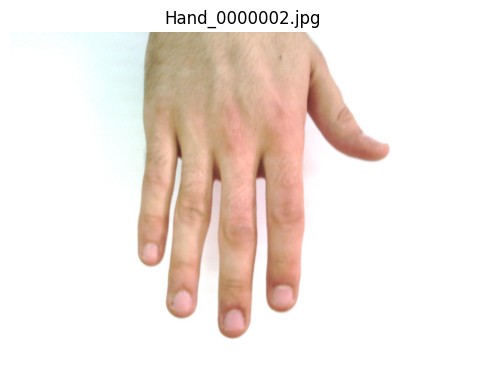

In [9]:
img = Image.open(image_path)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title(image_name)
plt.show()

In [10]:
# Choose the first image
image_name = df.loc[0, "imageName"]

image_path = os.path.join(image_folder, image_name)

print(image_path)

/kaggle/input/hands-and-palm-images-dataset/Hands/Hands/Hand_0000002.jpg


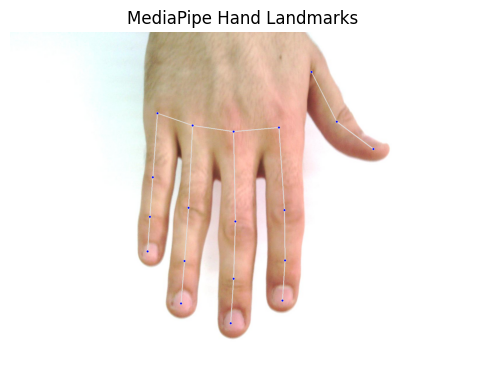

In [12]:
image = cv2.imread(image_path)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

results = hands.process(image_rgb)

if results.multi_hand_landmarks:

    for hand_landmarks in results.multi_hand_landmarks:

        mp_draw.draw_landmarks(
            image_rgb,
            hand_landmarks,
            mp_hands.HAND_CONNECTIONS
        )

plt.figure(figsize=(6,6))
plt.imshow(image_rgb)
plt.title("MediaPipe Hand Landmarks")
plt.axis("off")
plt.show()

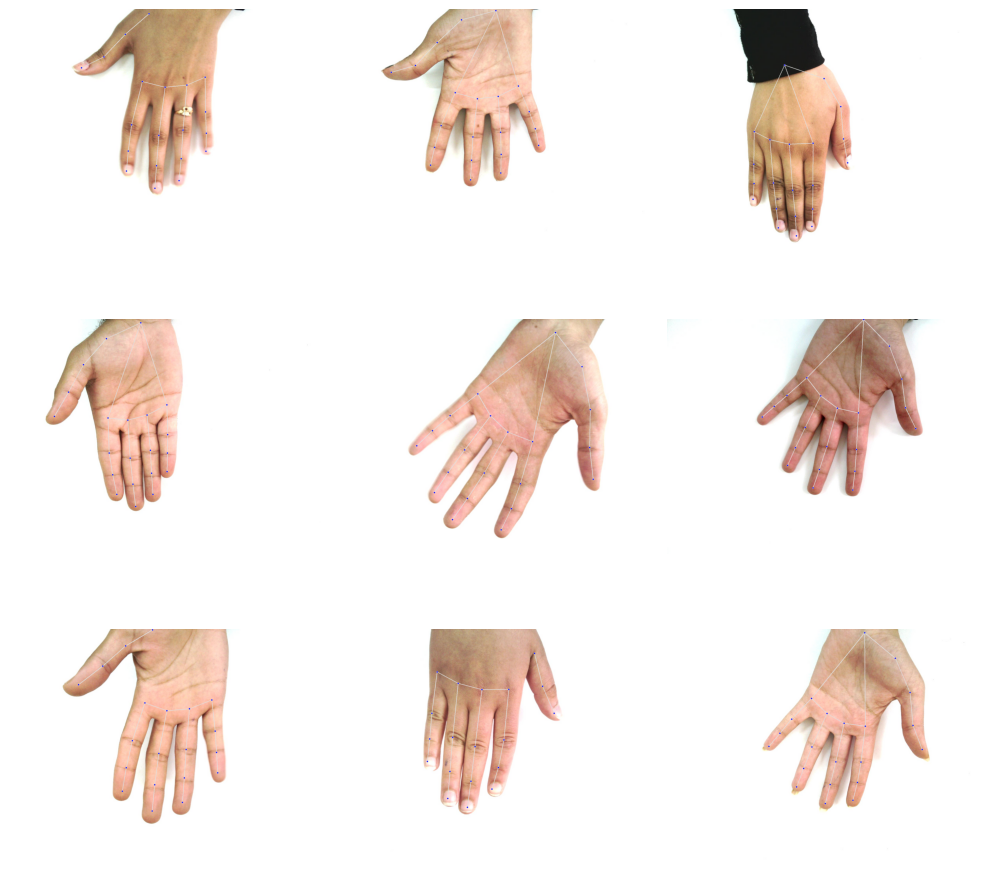

In [13]:
sample_images = df.sample(9, random_state=42)

plt.figure(figsize=(10,10))

for i, (_, row) in enumerate(sample_images.iterrows()):

    img_path = os.path.join(image_folder, row["imageName"])

    image = cv2.imread(img_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    results = hands.process(image_rgb)

    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            mp_draw.draw_landmarks(
                image_rgb,
                hand_landmarks,
                mp_hands.HAND_CONNECTIONS
            )

    plt.subplot(3,3,i+1)
    plt.imshow(image_rgb)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Count Images Where MediaPipe Detects a Hand

In [16]:
detected = 0
total = 100

for image_name in df["imageName"][:total]:

    img_path = os.path.join(image_folder, image_name)

    image = cv2.imread(img_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    results = hands.process(image_rgb)

    if results.multi_hand_landmarks:
        detected += 1

print(f"Detected Hands: {detected}")
print(f"Detection Rate: {detected/total*100:.2f}%")

Detected Hands: 99
Detection Rate: 99.00%


# Print the 21 Landmark Coordinates

In [18]:
if results.multi_hand_landmarks:

    hand = results.multi_hand_landmarks[0]

    for i, landmark in enumerate(hand.landmark):

        print(
            f"Point {i}: "
            f"x={landmark.x:.4f}, "
            f"y={landmark.y:.4f}, "
            f"z={landmark.z:.4f}"
        )

Point 0: x=0.5691, y=-0.1832, z=0.0000
Point 1: x=0.6649, y=-0.0939, z=-0.0439
Point 2: x=0.7160, y=0.0563, z=-0.0791
Point 3: x=0.7484, y=0.2037, z=-0.1058
Point 4: x=0.7900, y=0.3248, z=-0.1330
Point 5: x=0.6087, y=0.1767, z=-0.1062
Point 6: x=0.6051, y=0.4067, z=-0.1536
Point 7: x=0.5978, y=0.5353, z=-0.1738
Point 8: x=0.5858, y=0.6333, z=-0.1831
Point 9: x=0.5273, y=0.1591, z=-0.1066
Point 10: x=0.5231, y=0.4004, z=-0.1522
Point 11: x=0.5145, y=0.5452, z=-0.1716
Point 12: x=0.5018, y=0.6525, z=-0.1819
Point 13: x=0.4563, y=0.1224, z=-0.1077
Point 14: x=0.4453, y=0.3465, z=-0.1520
Point 15: x=0.4412, y=0.4832, z=-0.1733
Point 16: x=0.4376, y=0.5889, z=-0.1831
Point 17: x=0.3901, y=0.0742, z=-0.1092
Point 18: x=0.3582, y=0.2481, z=-0.1498
Point 19: x=0.3470, y=0.3570, z=-0.1675
Point 20: x=0.3424, y=0.4524, z=-0.1749


# Final Summary – MediaPipe Hand Landmark Detection
*   MediaPipe was used to detect 21 hand landmarks (key points) from hand images.
*   The detected landmarks accurately represent the palm, fingers, and wrist, enabling precise hand feature extraction.
*   Landmark detection helps identify the hand region and supports consistent image preprocessing.
*  These landmarks can be used for hand alignment, palm cropping, and feature extraction before model training.
*  For the Palmistry & Tarot Intelligence Platform, MediaPipe improves the quality of palm image analysis by providing structured hand key points.
*  Overall, MediaPipe is an effective preprocessing tool that enhances the accuracy and reliability of AI-based palm analysis.